In [0]:

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Initialize Spark Session
spark = SparkSession.builder.appName("NetflixAnalysis").getOrCreate()

In [0]:
# Load data
df = spark.read.csv("/Volumes/workspace/default/netflix/netflix_clean_dataset_kshitij_.csv", header=True, inferSchema=True)

# Remove rows with nulls in key columns
df = df.dropna(subset=["type", "rating", "release_year", "duration_int", "added_year"])


In [0]:

# Feature Engineering
indexer_type = StringIndexer(inputCol="type", outputCol="type_idx", handleInvalid="skip")
indexer_rating = StringIndexer(inputCol="rating", outputCol="rating_idx", handleInvalid="skip")

df = indexer_type.fit(df).transform(df)
df = indexer_rating.fit(df).transform(df)

# Prepare features
feature_cols = ["release_year", "duration_int", "added_year", "type_idx", "rating_idx"]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)
df = assembler.transform(df).select("features", "type_idx", "rating_idx")


print("CLASSIFICATION OF CONTENT TYPE (MOVIE VS. TV SHOW)")


# Split data
train, test = df.randomSplit([0.8, 0.2], seed=42)

# Train Random Forest classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="type_idx", numTrees=100, seed=42)
model_rf = rf.fit(train)
predictions = model_rf.transform(test)

# Evaluate
evaluator = MulticlassClassificationEvaluator(labelCol="type_idx", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Generate Classification Report
from sklearn.metrics import classification_report

pred_df = predictions.select("type_idx", "prediction").toPandas()
y_true = pred_df["type_idx"].values.astype(int)
y_pred = pred_df["prediction"].values.astype(int)

# Get label mapping
type_labels = ['Movie', 'TV Show'] if len(set(y_true)) == 2 else [f'Class {i}' for i in sorted(set(y_true))]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=type_labels, digits=2))

# Convert Classification Report to DataFrame for tabular display
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

# Create detailed report dataframe
report_data = []
for i, label in enumerate(type_labels):
    report_data.append({
        'Class': label,
        'Precision': f'{precision[i]:.2f}',
        'Recall': f'{recall[i]:.2f}',
        'F1-Score': f'{f1[i]:.2f}',
        'Support': int(support[i])
    })


CLASSIFICATION OF CONTENT TYPE (MOVIE VS. TV SHOW)

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00       515
     TV Show       1.00      1.00      1.00       250

    accuracy                           1.00       765
   macro avg       1.00      1.00      1.00       765
weighted avg       1.00      1.00      1.00       765



In [0]:

macro_precision = precision.mean()
macro_recall = recall.mean()
macro_f1 = f1.mean()
weighted_precision = (precision * support).sum() / support.sum()
weighted_recall = (recall * support).sum() / support.sum()
weighted_f1 = (f1 * support).sum() / support.sum()

report_data.append({
    'Class': 'Macro Avg',
    'Precision': f'{macro_precision:.2f}',
    'Recall': f'{macro_recall:.2f}',
    'F1-Score': f'{macro_f1:.2f}',
    'Support': int(support.sum())
})

report_data.append({
    'Class': 'Weighted Avg',
    'Precision': f'{weighted_precision:.2f}',
    'Recall': f'{weighted_recall:.2f}',
    'F1-Score': f'{weighted_f1:.2f}',
    'Support': int(support.sum())
})

report_df = pd.DataFrame(report_data)
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - TABULAR FORMAT")
print("=" * 70)
print(report_df.to_string(index=False))


CLASSIFICATION REPORT - TABULAR FORMAT
       Class Precision Recall F1-Score  Support
       Movie      1.00   1.00     1.00      515
     TV Show      1.00   1.00     1.00      250
   Macro Avg      1.00   1.00     1.00      765
Weighted Avg      1.00   1.00     1.00      765


FEATURE IMPORTANCE

Feature Importance Scores:
     Feature  Importance
    type_idx    0.605850
duration_int    0.387574
  rating_idx    0.006283
release_year    0.000275
  added_year    0.000017


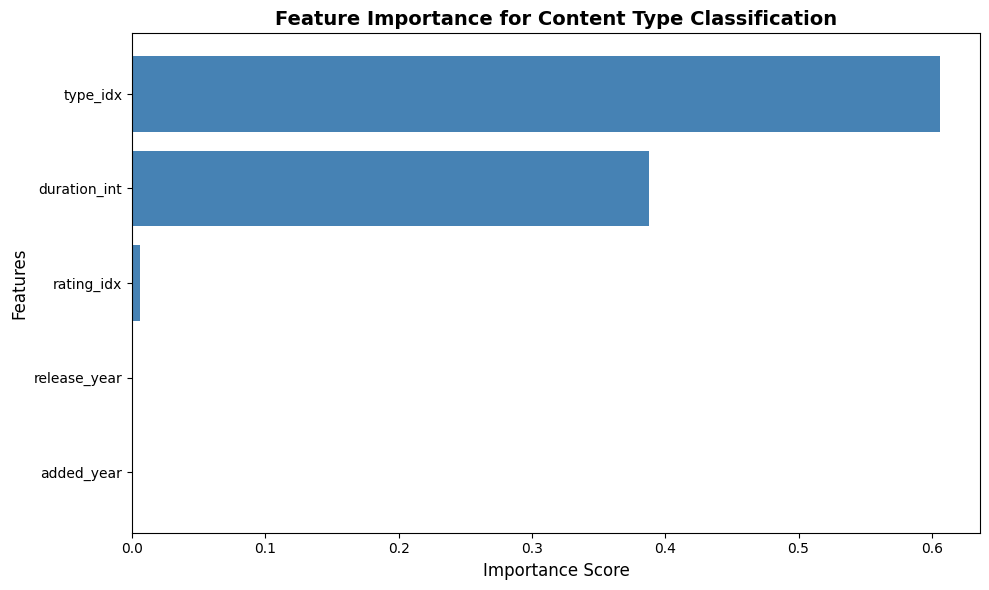

In [0]:

print("FEATURE IMPORTANCE")


# Extract feature importance
feature_importance = model_rf.featureImportances.toArray()
feature_names = feature_cols

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance for Content Type Classification', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
display(plt.show())

CONFUSION MATRIX

Confusion Matrix:
[[515   0]
 [  0 250]]

Total Predictions: 765
Correct Predictions: 765
Misclassifications: 0


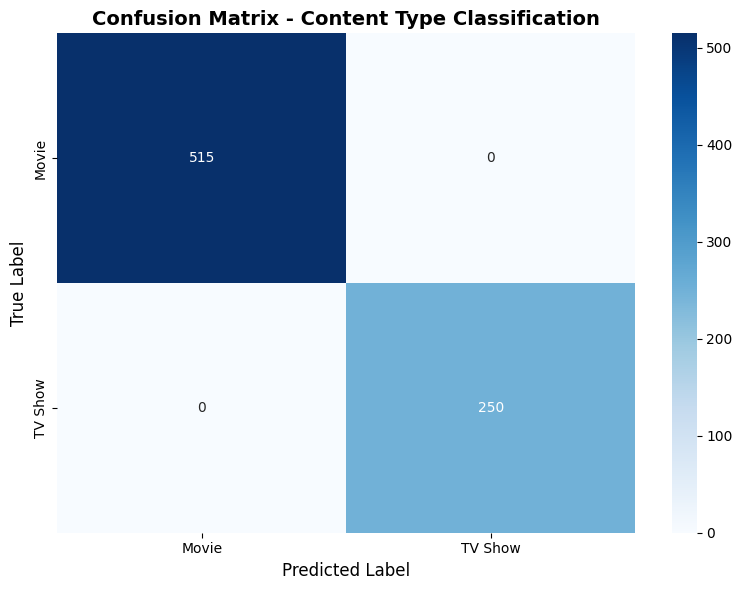

In [0]:
print("CONFUSION MATRIX")


# Compute confusion matrix (y_true and y_pred already defined above)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Calculate additional metrics from confusion matrix
total = cm.sum()
correct = np.trace(cm)
print(f"\nTotal Predictions: {total}")
print(f"Correct Predictions: {correct}")
print(f"Misclassifications: {total - correct}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Content Type Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
display(plt.show())


In [0]:

print("APPLY K-MEANS CLUSTERING")


# Apply K-Means clustering
kmeans = KMeans(k=3, seed=42, featuresCol="features", predictionCol="cluster")
model_kmeans = kmeans.fit(df)
clustered = model_kmeans.transform(df)

print(f"\nWithin Set Sum of Squared Errors (WSSSE): {model_kmeans.summary.trainingCost:.2f}")
print("\nCluster Distribution:")
clustered.groupBy("cluster").count().orderBy("cluster").show()

# Get cluster centers
centers = model_kmeans.clusterCenters()
print("Cluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

APPLY K-MEANS CLUSTERING

Within Set Sum of Squared Errors (WSSSE): 1139389.41

Cluster Distribution:
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 1376|
|      1|  856|
|      2| 1865|
+-------+-----+

Cluster Centers:
Cluster 0: [2.01655015e+03 4.02761628e+00 2.01889535e+03 9.22965116e-01
 1.79215116e+00]
Cluster 1: [2.01061682e+03 1.31186916e+02 2.01903271e+03 0.00000000e+00
 1.82126168e+00]
Cluster 2: [2.01412064e+03 8.98155496e+01 2.01875067e+03 0.00000000e+00
 1.99678284e+00]


VISUALIZATION - CLUSTERING


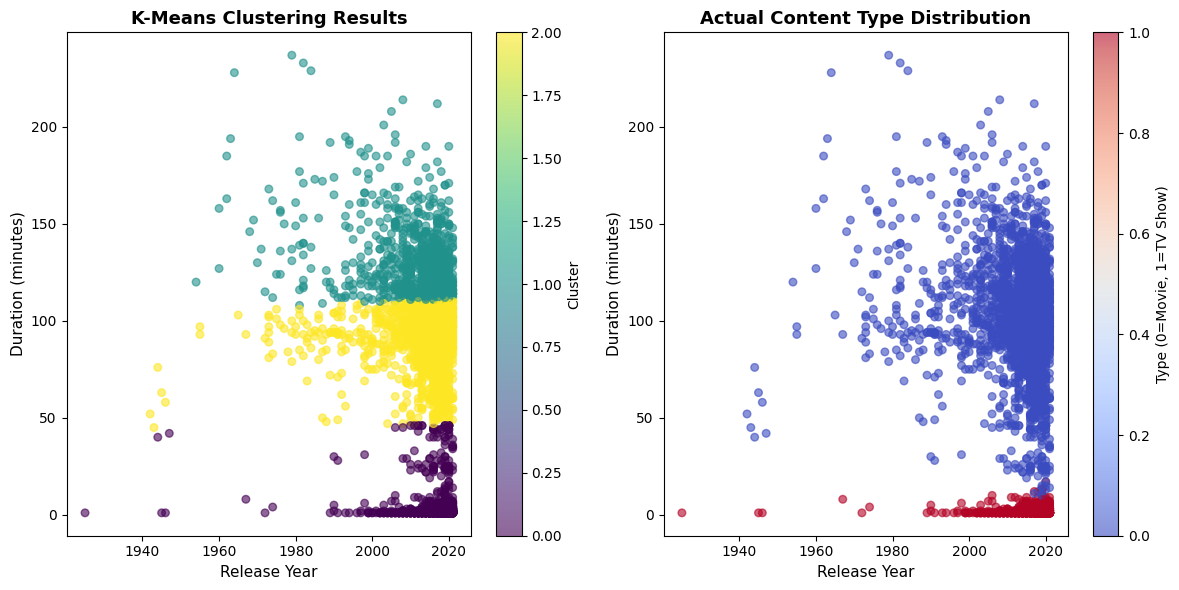

In [0]:

print("VISUALIZATION - CLUSTERING")


# Convert to Pandas for visualization
cluster_df = clustered.select("features", "cluster", "type_idx").toPandas()

# Extract first two features for 2D visualization
from pyspark.ml.linalg import Vectors
cluster_df['feature_0'] = cluster_df['features'].apply(lambda x: float(x[0]))
cluster_df['feature_1'] = cluster_df['features'].apply(lambda x: float(x[1]))

# Plot clusters
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(cluster_df['feature_0'], cluster_df['feature_1'], 
                     c=cluster_df['cluster'], cmap='viridis', alpha=0.6, s=30)
plt.xlabel('Release Year', fontsize=11)
plt.ylabel('Duration (minutes)', fontsize=11)
plt.title('K-Means Clustering Results', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(cluster_df['feature_0'], cluster_df['feature_1'], 
                      c=cluster_df['type_idx'], cmap='coolwarm', alpha=0.6, s=30)
plt.xlabel('Release Year', fontsize=11)
plt.ylabel('Duration (minutes)', fontsize=11)
plt.title('Actual Content Type Distribution', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, label='Type (0=Movie, 1=TV Show)')

plt.tight_layout()
display(plt.show())


ELBOW METHOD - FINDING OPTIMAL K
K=2: WSSSE = 2122033.91
K=3: WSSSE = 1139389.41
K=4: WSSSE = 812439.28
K=5: WSSSE = 778550.48
K=6: WSSSE = 518792.30
K=7: WSSSE = 444635.99
K=8: WSSSE = 408379.39
K=9: WSSSE = 365548.26
K=10: WSSSE = 330764.48


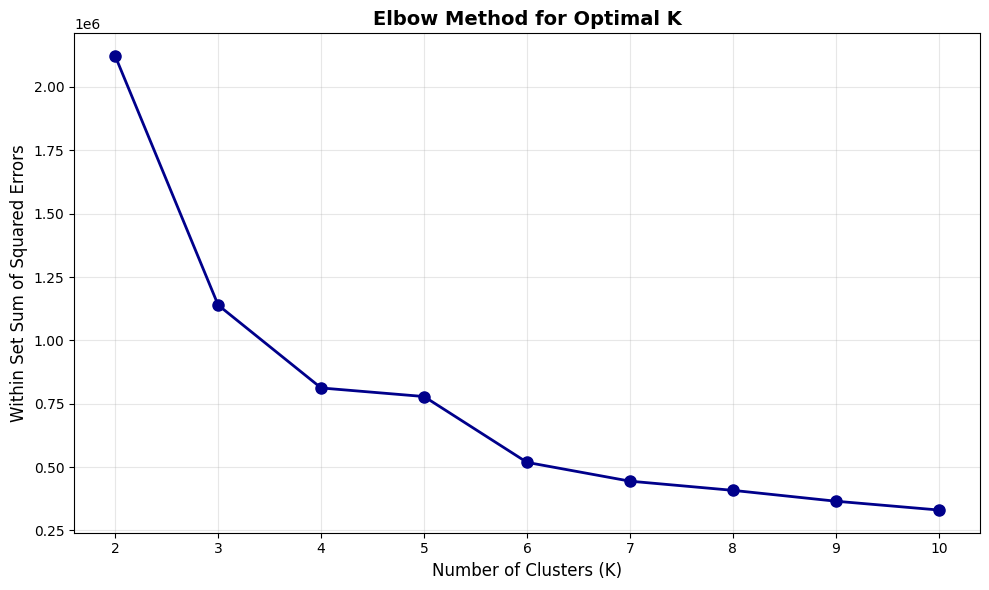

ANALYSIS COMPLETE!


In [0]:
# Elbow Method for optimal K
print("\n" + "=" * 70)
print("ELBOW METHOD - FINDING OPTIMAL K")
print("=" * 70)

wssse_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans_temp = KMeans(k=k, seed=42, featuresCol="features")
    model_temp = kmeans_temp.fit(df)
    wssse_values.append(model_temp.summary.trainingCost)
    print(f"K={k}: WSSSE = {model_temp.summary.trainingCost:.2f}")

# Plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, wssse_values, marker='o', linewidth=2, markersize=8, color='darkblue')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within Set Sum of Squared Errors', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
display(plt.show())

print("ANALYSIS COMPLETE!")